Number of communities: 3
Total number of nodes (colleges): 31

Community 0: ['17', '28', '10', '16', '11', '18', '13', '14', '19', '30', '15', '27', '25', '26', '9', '12', '20']
Community 1: ['4', '5', '21', '6', '7', '8', '29', '24']
Community 2: ['0', '1', '2', '3', '23', '22']

Modularity: 0.389888
Coverage: 0.710526
Performance: 0.787097


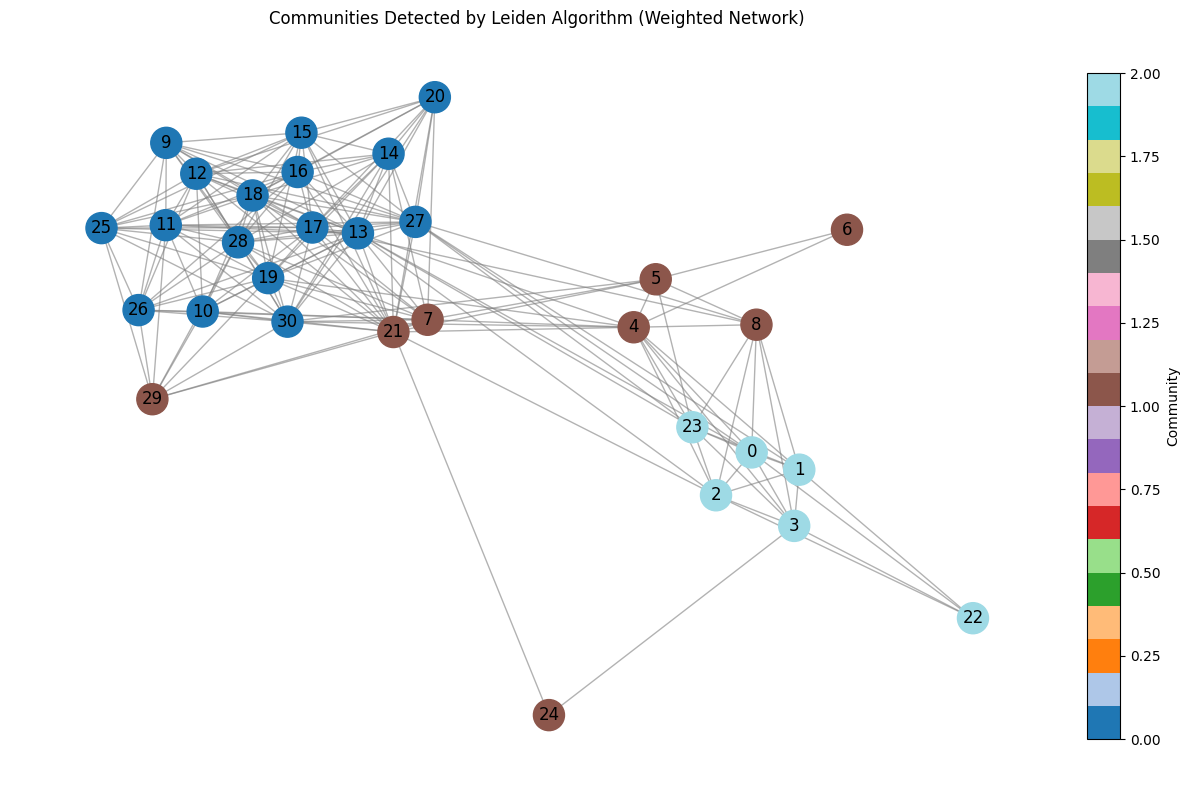

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import leidenalg as la
import igraph as ig

# 读取图数据（每行：学院1 学院2 公共课程数）
G_nx = nx.read_weighted_edgelist('courses1.txt')
G_nx = G_nx.to_undirected()

# 度中心性（用于可视化参考，基于无权连接数）
degree_centrality = nx.degree_centrality(G_nx)

# === 转换为 igraph 格式（leidenalg 依赖 igraph）===
node_list = list(G_nx.nodes())
node_to_idx = {node: idx for idx, node in enumerate(node_list)}
idx_to_node = {idx: node for node, idx in node_to_idx.items()}

# 构建边和权重列表（按 igraph 节点索引）
edges = [(node_to_idx[u], node_to_idx[v]) for u, v in G_nx.edges()]
weights = [G_nx[u][v]['weight'] for u, v in G_nx.edges()]

# 创建 igraph 图
G_ig = ig.Graph()
G_ig.add_vertices(len(node_list))
G_ig.add_edges(edges)
G_ig.es['weight'] = weights  # 设置边权重

# === 使用 Leiden 算法（使用 RB 分区以支持 resolution_parameter）===
partition_ig = la.find_partition(
    G_ig,
    la.RBConfigurationVertexPartition,
    weights='weight',
    resolution_parameter=1.0,  # ≈ 标准模块度；可调（>1 更细，<1 更粗）
    seed=42  # 部分版本支持，确保可复现
)

# 获取社区分配（membership 是节点索引对应的社区 ID 列表）
community_ids = partition_ig.membership

# 映射回原始节点名称
community_map = {}
communities_dict = {}
for idx, comm_id in enumerate(community_ids):
    node = idx_to_node[idx]
    community_map[node] = comm_id
    communities_dict.setdefault(comm_id, []).append(node)

# 转为 list of lists（用于 NetworkX 指标计算）
communities = list(communities_dict.values())

# === 打印基本信息 ===
num_communities = len(communities)
total_nodes = G_nx.number_of_nodes()
print(f"Number of communities: {num_communities}")
print(f"Total number of nodes (colleges): {total_nodes}\n")

# 按社区 ID 排序输出成员
for comm_id in sorted(communities_dict.keys()):
    print(f"Community {comm_id}: {communities_dict[comm_id]}")
print()

# === 计算标准模块度（使用 NetworkX，确保与贪心/Louvain 可比）===
# 注意：必须转为 list of sets 或 list of lists
modularity_value = nx.algorithms.community.modularity(G_nx, communities, weight='weight')
print(f"Modularity: {modularity_value:.6f}")

# === 覆盖度（Coverage）===
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G_nx, community_map)
print(f"Coverage: {coverage_value:.6f}")

# === 表现评分（Performance）===
def compute_performance(G, communities, community_map):
    n = G.number_of_nodes()
    total_possible = n * (n - 1) / 2
    actual_edges = set(tuple(sorted(e)) for e in G.edges())
    
    intra_edges = sum(1 for u, v in actual_edges if community_map[u] == community_map[v])
    inter_edges = len(actual_edges) - intra_edges
    
    possible_intra = sum(len(c) * (len(c) - 1) / 2 for c in communities)
    possible_inter = total_possible - possible_intra
    
    missing_inter = possible_inter - inter_edges  # 应无边且确实无边
    correct = intra_edges + missing_inter
    
    return correct / total_possible if total_possible > 0 else 0

performance_value = compute_performance(G_nx, communities, community_map)
print(f"Performance: {performance_value:.6f}")

# === 可视化 ===
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_nx, seed=42)  # 固定布局

# 节点颜色（按社区 ID）
community_colors = [community_map[node] for node in G_nx.nodes()]

nx.draw_networkx_nodes(G_nx, pos, node_color=community_colors, cmap=plt.cm.tab20, node_size=500)
nx.draw_networkx_labels(G_nx, pos, font_size=12)
nx.draw_networkx_edges(G_nx, pos, edge_color='gray', width=1, alpha=0.6)

# 添加颜色条
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Communities Detected by Leiden Algorithm (Weighted Network)')
plt.gca().set_facecolor('white')
plt.axis('off')
plt.tight_layout()
plt.show()

Number of communities: 4
Total number of nodes (colleges): 30

Community 0: ['17', '28', '16', '11', '18', '13', '14', '15', '27', '25', '9', '12', '20']
Community 1: ['10', '19', '30', '21', '26', '7', '29']
Community 2: ['0', '1', '2', '3', '23', '22']
Community 3: ['4', '5', '6', '8']

Modularity: 0.450066
Coverage: 0.737705
Performance: 0.857471


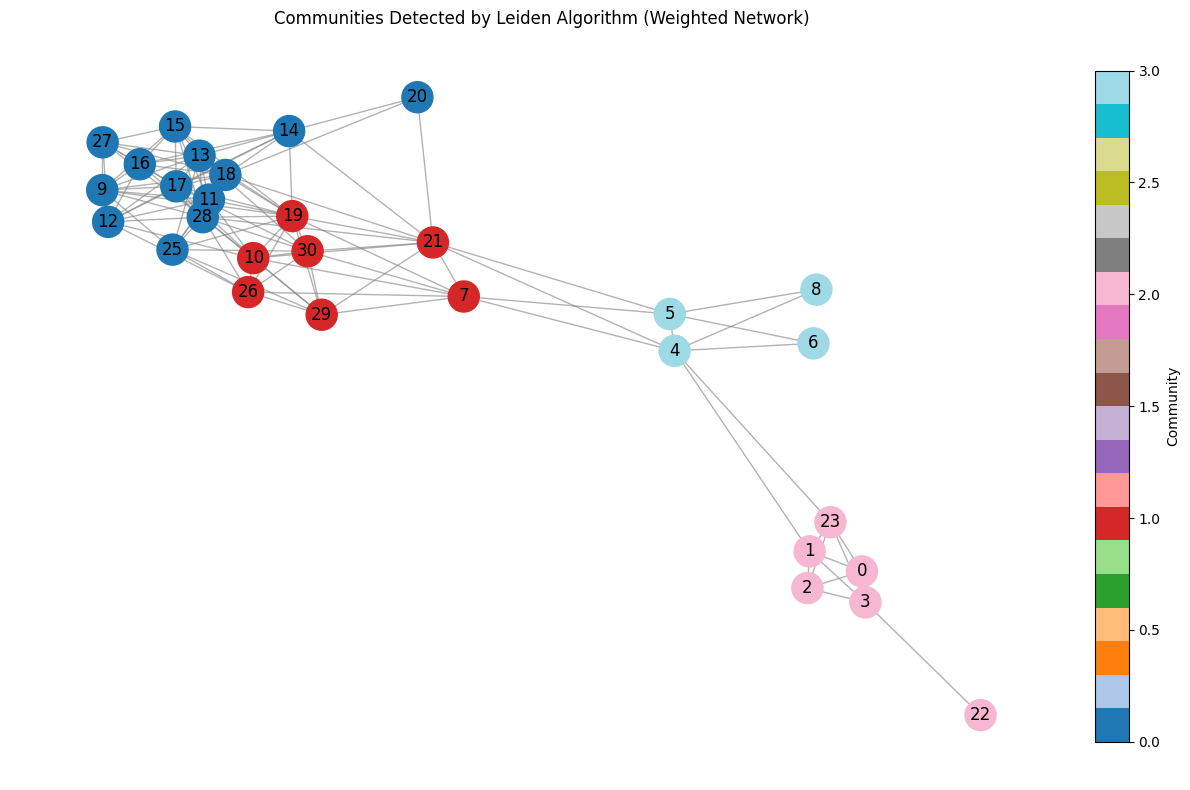

In [9]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import leidenalg as la
import igraph as ig

# 读取图数据（每行：学院1 学院2 公共课程数）
G_nx = nx.read_weighted_edgelist('courses2.txt')
G_nx = G_nx.to_undirected()

# 度中心性（用于可视化参考，基于无权连接数）
degree_centrality = nx.degree_centrality(G_nx)

# === 转换为 igraph 格式（leidenalg 依赖 igraph）===
node_list = list(G_nx.nodes())
node_to_idx = {node: idx for idx, node in enumerate(node_list)}
idx_to_node = {idx: node for node, idx in node_to_idx.items()}

# 构建边和权重列表（按 igraph 节点索引）
edges = [(node_to_idx[u], node_to_idx[v]) for u, v in G_nx.edges()]
weights = [G_nx[u][v]['weight'] for u, v in G_nx.edges()]

# 创建 igraph 图
G_ig = ig.Graph()
G_ig.add_vertices(len(node_list))
G_ig.add_edges(edges)
G_ig.es['weight'] = weights  # 设置边权重

# === 使用 Leiden 算法（使用 RB 分区以支持 resolution_parameter）===
partition_ig = la.find_partition(
    G_ig,
    la.RBConfigurationVertexPartition,
    weights='weight',
    resolution_parameter=1.0,  # ≈ 标准模块度；可调（>1 更细，<1 更粗）
    seed=42  # 部分版本支持，确保可复现
)

# 获取社区分配（membership 是节点索引对应的社区 ID 列表）
community_ids = partition_ig.membership

# 映射回原始节点名称
community_map = {}
communities_dict = {}
for idx, comm_id in enumerate(community_ids):
    node = idx_to_node[idx]
    community_map[node] = comm_id
    communities_dict.setdefault(comm_id, []).append(node)

# 转为 list of lists（用于 NetworkX 指标计算）
communities = list(communities_dict.values())

# === 打印基本信息 ===
num_communities = len(communities)
total_nodes = G_nx.number_of_nodes()
print(f"Number of communities: {num_communities}")
print(f"Total number of nodes (colleges): {total_nodes}\n")

# 按社区 ID 排序输出成员
for comm_id in sorted(communities_dict.keys()):
    print(f"Community {comm_id}: {communities_dict[comm_id]}")
print()

# === 计算标准模块度（使用 NetworkX，确保与贪心/Louvain 可比）===
# 注意：必须转为 list of sets 或 list of lists
modularity_value = nx.algorithms.community.modularity(G_nx, communities, weight='weight')
print(f"Modularity: {modularity_value:.6f}")

# === 覆盖度（Coverage）===
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G_nx, community_map)
print(f"Coverage: {coverage_value:.6f}")

# === 表现评分（Performance）===
def compute_performance(G, communities, community_map):
    n = G.number_of_nodes()
    total_possible = n * (n - 1) / 2
    actual_edges = set(tuple(sorted(e)) for e in G.edges())
    
    intra_edges = sum(1 for u, v in actual_edges if community_map[u] == community_map[v])
    inter_edges = len(actual_edges) - intra_edges
    
    possible_intra = sum(len(c) * (len(c) - 1) / 2 for c in communities)
    possible_inter = total_possible - possible_intra
    
    missing_inter = possible_inter - inter_edges  # 应无边且确实无边
    correct = intra_edges + missing_inter
    
    return correct / total_possible if total_possible > 0 else 0

performance_value = compute_performance(G_nx, communities, community_map)
print(f"Performance: {performance_value:.6f}")

# === 可视化 ===
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_nx, seed=42)  # 固定布局

# 节点颜色（按社区 ID）
community_colors = [community_map[node] for node in G_nx.nodes()]

nx.draw_networkx_nodes(G_nx, pos, node_color=community_colors, cmap=plt.cm.tab20, node_size=500)
nx.draw_networkx_labels(G_nx, pos, font_size=12)
nx.draw_networkx_edges(G_nx, pos, edge_color='gray', width=1, alpha=0.6)

# 添加颜色条
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Communities Detected by Leiden Algorithm (Weighted Network)')
plt.gca().set_facecolor('white')
plt.axis('off')
plt.tight_layout()
plt.show()

Number of communities: 4
Total number of nodes (colleges): 29

Community 0: ['17', '28', '16', '11', '18', '13', '14', '15', '27', '25', '9', '12', '20']
Community 1: ['0', '1', '2', '3', '23', '22']
Community 2: ['10', '19', '30', '21', '26', '7']
Community 3: ['4', '5', '6', '8']

Modularity: 0.472552
Coverage: 0.795455
Performance: 0.847291


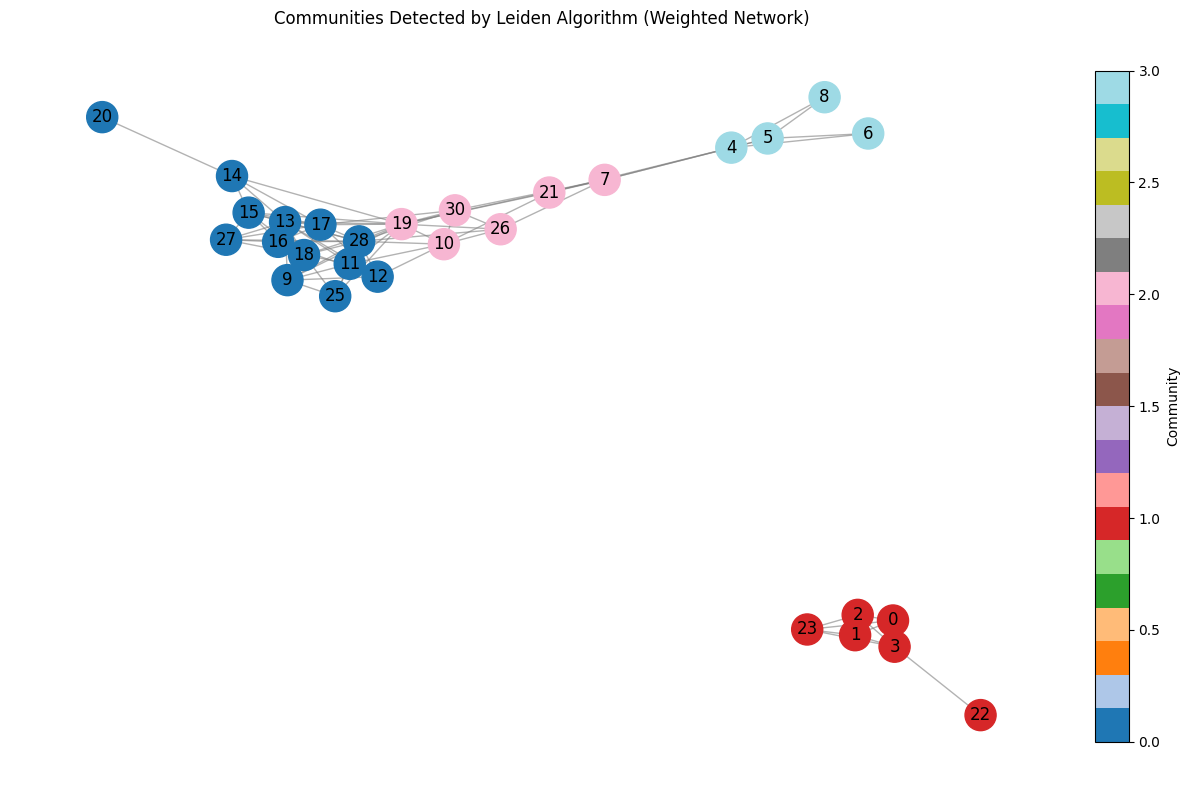

In [10]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import leidenalg as la
import igraph as ig

# 读取图数据（每行：学院1 学院2 公共课程数）
G_nx = nx.read_weighted_edgelist('courses3.txt')
G_nx = G_nx.to_undirected()

# 度中心性（用于可视化参考，基于无权连接数）
degree_centrality = nx.degree_centrality(G_nx)

# === 转换为 igraph 格式（leidenalg 依赖 igraph）===
node_list = list(G_nx.nodes())
node_to_idx = {node: idx for idx, node in enumerate(node_list)}
idx_to_node = {idx: node for node, idx in node_to_idx.items()}

# 构建边和权重列表（按 igraph 节点索引）
edges = [(node_to_idx[u], node_to_idx[v]) for u, v in G_nx.edges()]
weights = [G_nx[u][v]['weight'] for u, v in G_nx.edges()]

# 创建 igraph 图
G_ig = ig.Graph()
G_ig.add_vertices(len(node_list))
G_ig.add_edges(edges)
G_ig.es['weight'] = weights  # 设置边权重

# === 使用 Leiden 算法（使用 RB 分区以支持 resolution_parameter）===
partition_ig = la.find_partition(
    G_ig,
    la.RBConfigurationVertexPartition,
    weights='weight',
    resolution_parameter=1.0,  # ≈ 标准模块度；可调（>1 更细，<1 更粗）
    seed=42  # 部分版本支持，确保可复现
)

# 获取社区分配（membership 是节点索引对应的社区 ID 列表）
community_ids = partition_ig.membership

# 映射回原始节点名称
community_map = {}
communities_dict = {}
for idx, comm_id in enumerate(community_ids):
    node = idx_to_node[idx]
    community_map[node] = comm_id
    communities_dict.setdefault(comm_id, []).append(node)

# 转为 list of lists（用于 NetworkX 指标计算）
communities = list(communities_dict.values())

# === 打印基本信息 ===
num_communities = len(communities)
total_nodes = G_nx.number_of_nodes()
print(f"Number of communities: {num_communities}")
print(f"Total number of nodes (colleges): {total_nodes}\n")

# 按社区 ID 排序输出成员
for comm_id in sorted(communities_dict.keys()):
    print(f"Community {comm_id}: {communities_dict[comm_id]}")
print()

# === 计算标准模块度（使用 NetworkX，确保与贪心/Louvain 可比）===
# 注意：必须转为 list of sets 或 list of lists
modularity_value = nx.algorithms.community.modularity(G_nx, communities, weight='weight')
print(f"Modularity: {modularity_value:.6f}")

# === 覆盖度（Coverage）===
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G_nx, community_map)
print(f"Coverage: {coverage_value:.6f}")

# === 表现评分（Performance）===
def compute_performance(G, communities, community_map):
    n = G.number_of_nodes()
    total_possible = n * (n - 1) / 2
    actual_edges = set(tuple(sorted(e)) for e in G.edges())
    
    intra_edges = sum(1 for u, v in actual_edges if community_map[u] == community_map[v])
    inter_edges = len(actual_edges) - intra_edges
    
    possible_intra = sum(len(c) * (len(c) - 1) / 2 for c in communities)
    possible_inter = total_possible - possible_intra
    
    missing_inter = possible_inter - inter_edges  # 应无边且确实无边
    correct = intra_edges + missing_inter
    
    return correct / total_possible if total_possible > 0 else 0

performance_value = compute_performance(G_nx, communities, community_map)
print(f"Performance: {performance_value:.6f}")

# === 可视化 ===
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_nx, seed=42)  # 固定布局

# 节点颜色（按社区 ID）
community_colors = [community_map[node] for node in G_nx.nodes()]

nx.draw_networkx_nodes(G_nx, pos, node_color=community_colors, cmap=plt.cm.tab20, node_size=500)
nx.draw_networkx_labels(G_nx, pos, font_size=12)
nx.draw_networkx_edges(G_nx, pos, edge_color='gray', width=1, alpha=0.6)

# 添加颜色条
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Communities Detected by Leiden Algorithm (Weighted Network)')
plt.gca().set_facecolor('white')
plt.axis('off')
plt.tight_layout()
plt.show()

Number of communities: 4
Total number of nodes (colleges): 29

Community 0: ['17', '28', '16', '11', '18', '13', '14', '15', '27', '25', '9', '12', '20']
Community 1: ['0', '1', '2', '3', '23', '22']
Community 2: ['10', '19', '30', '21', '26', '7']
Community 3: ['4', '5', '6', '8']

Modularity: 0.472552
Coverage: 0.795455
Performance: 0.950276


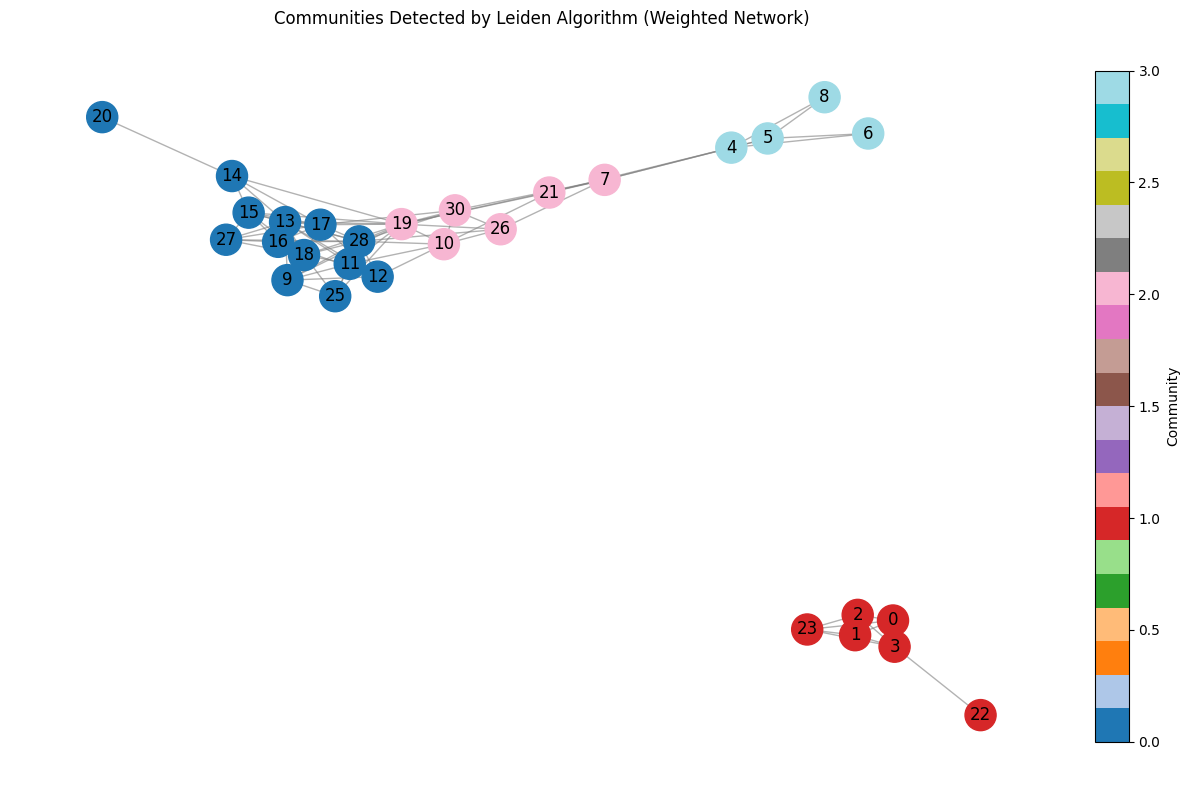

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import leidenalg as la
import igraph as ig

# 读取图数据（每行：学院1 学院2 公共课程数）
G_nx = nx.read_weighted_edgelist('courses3.txt')
G_nx = G_nx.to_undirected()

# 度中心性（用于可视化参考，基于无权连接数）
degree_centrality = nx.degree_centrality(G_nx)

# === 转换为 igraph 格式（leidenalg 依赖 igraph）===
node_list = list(G_nx.nodes())
node_to_idx = {node: idx for idx, node in enumerate(node_list)}
idx_to_node = {idx: node for node, idx in node_to_idx.items()}

# 构建边和权重列表（按 igraph 节点索引）
edges = [(node_to_idx[u], node_to_idx[v]) for u, v in G_nx.edges()]
weights = [G_nx[u][v]['weight'] for u, v in G_nx.edges()]

# 创建 igraph 图
G_ig = ig.Graph()
G_ig.add_vertices(len(node_list))
G_ig.add_edges(edges)
G_ig.es['weight'] = weights  # 设置边权重

# === 使用 Leiden 算法（使用 RB 分区以支持 resolution_parameter）===
partition_ig = la.find_partition(
    G_ig,
    la.RBConfigurationVertexPartition,
    weights='weight',
    resolution_parameter=1.0,  # ≈ 标准模块度；可调（>1 更细，<1 更粗）
    seed=42  # 部分版本支持，确保可复现
)

# 获取社区分配（membership 是节点索引对应的社区 ID 列表）
community_ids = partition_ig.membership

# 映射回原始节点名称
community_map = {}
communities_dict = {}
for idx, comm_id in enumerate(community_ids):
    node = idx_to_node[idx]
    community_map[node] = comm_id
    communities_dict.setdefault(comm_id, []).append(node)

# 转为 list of lists（用于 NetworkX 指标计算）
communities = list(communities_dict.values())

# === 打印基本信息 ===
num_communities = len(communities)
total_nodes = G_nx.number_of_nodes()
print(f"Number of communities: {num_communities}")
print(f"Total number of nodes (colleges): {total_nodes}\n")

# 按社区 ID 排序输出成员
for comm_id in sorted(communities_dict.keys()):
    print(f"Community {comm_id}: {communities_dict[comm_id]}")
print()

# === 计算标准模块度（使用 NetworkX，确保与贪心/Louvain 可比）===
# 注意：必须转为 list of sets 或 list of lists
modularity_value = nx.algorithms.community.modularity(G_nx, communities, weight='weight')
print(f"Modularity: {modularity_value:.6f}")

# === 覆盖度（Coverage）===
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G_nx, community_map)
print(f"Coverage: {coverage_value:.6f}")

# 手动实现表现评分
def compute_performance(G, communities):
    intra_edges = sum(1 for edge in G.edges() if community_map[edge[0]] == community_map[edge[1]])
    inter_edges = sum(1 for edge in G.edges() if community_map[edge[0]] != community_map[edge[1]])
    possible_intra_edges = sum(len(community) * (len(community) - 1) / 2 for community in communities)
    possible_inter_edges = len(G.nodes()) * (len(G.nodes()) - 1) / 2 - possible_intra_edges
    return (intra_edges + possible_inter_edges - inter_edges) / (intra_edges + inter_edges + possible_inter_edges - inter_edges)

performance_value = compute_performance(G_nx, communities)
print(f"Performance: {performance_value:.6f}")

# === 可视化 ===
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_nx, seed=42)  # 固定布局

# 节点颜色（按社区 ID）
community_colors = [community_map[node] for node in G_nx.nodes()]

nx.draw_networkx_nodes(G_nx, pos, node_color=community_colors, cmap=plt.cm.tab20, node_size=500)
nx.draw_networkx_labels(G_nx, pos, font_size=12)
nx.draw_networkx_edges(G_nx, pos, edge_color='gray', width=1, alpha=0.6)

# 添加颜色条
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Communities Detected by Leiden Algorithm (Weighted Network)')
plt.gca().set_facecolor('white')
plt.axis('off')
plt.tight_layout()
plt.show()

Number of communities: 4
Total number of nodes (colleges): 28

Community 0: ['17', '28', '16', '11', '18', '13', '14', '15', '27', '25', '9', '12', '20']
Community 1: ['10', '19', '30', '21', '26', '7']
Community 2: ['0', '1', '2', '3', '23']
Community 3: ['4', '5', '6', '8']

Modularity: 0.488777
Coverage: 0.816901
Performance: 0.830688


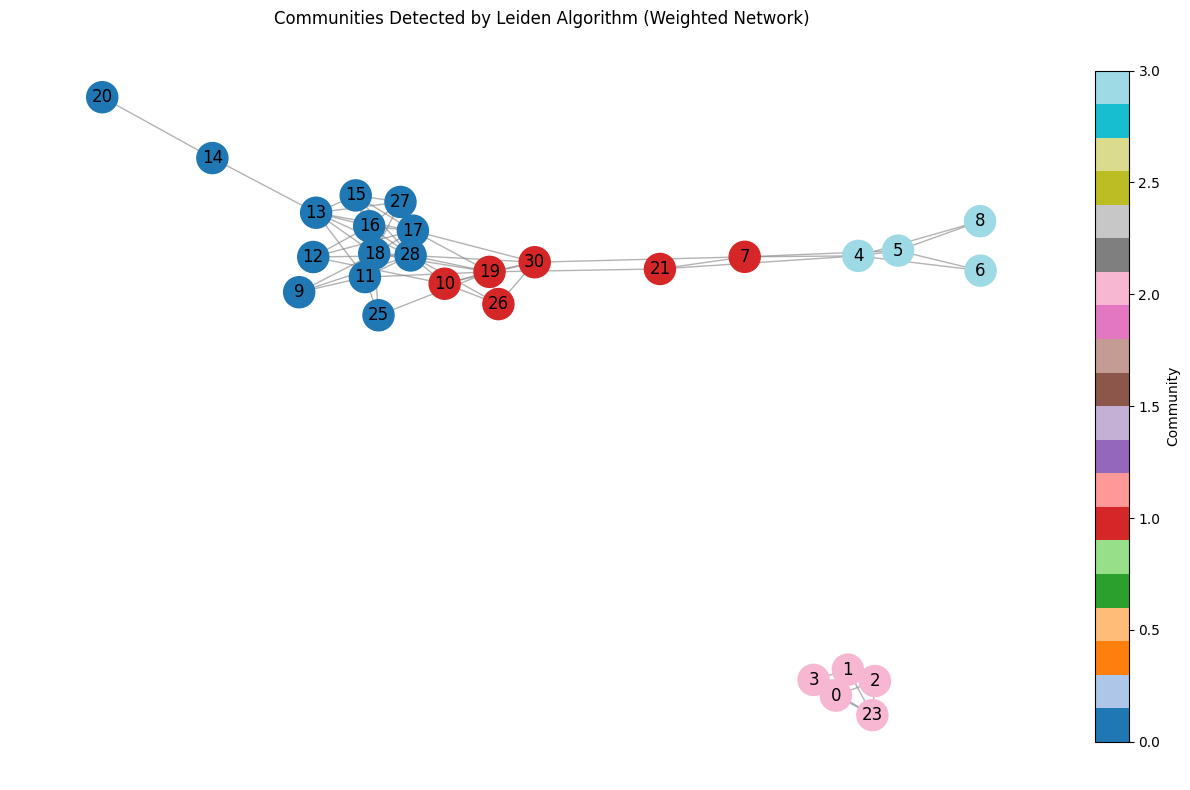

In [11]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import leidenalg as la
import igraph as ig

# 读取图数据（每行：学院1 学院2 公共课程数）
G_nx = nx.read_weighted_edgelist('courses4.txt')
G_nx = G_nx.to_undirected()

# 度中心性（用于可视化参考，基于无权连接数）
degree_centrality = nx.degree_centrality(G_nx)

# === 转换为 igraph 格式（leidenalg 依赖 igraph）===
node_list = list(G_nx.nodes())
node_to_idx = {node: idx for idx, node in enumerate(node_list)}
idx_to_node = {idx: node for node, idx in node_to_idx.items()}

# 构建边和权重列表（按 igraph 节点索引）
edges = [(node_to_idx[u], node_to_idx[v]) for u, v in G_nx.edges()]
weights = [G_nx[u][v]['weight'] for u, v in G_nx.edges()]

# 创建 igraph 图
G_ig = ig.Graph()
G_ig.add_vertices(len(node_list))
G_ig.add_edges(edges)
G_ig.es['weight'] = weights  # 设置边权重

# === 使用 Leiden 算法（使用 RB 分区以支持 resolution_parameter）===
partition_ig = la.find_partition(
    G_ig,
    la.RBConfigurationVertexPartition,
    weights='weight',
    resolution_parameter=1.0,  # ≈ 标准模块度；可调（>1 更细，<1 更粗）
    seed=42  # 部分版本支持，确保可复现
)

# 获取社区分配（membership 是节点索引对应的社区 ID 列表）
community_ids = partition_ig.membership

# 映射回原始节点名称
community_map = {}
communities_dict = {}
for idx, comm_id in enumerate(community_ids):
    node = idx_to_node[idx]
    community_map[node] = comm_id
    communities_dict.setdefault(comm_id, []).append(node)

# 转为 list of lists（用于 NetworkX 指标计算）
communities = list(communities_dict.values())

# === 打印基本信息 ===
num_communities = len(communities)
total_nodes = G_nx.number_of_nodes()
print(f"Number of communities: {num_communities}")
print(f"Total number of nodes (colleges): {total_nodes}\n")

# 按社区 ID 排序输出成员
for comm_id in sorted(communities_dict.keys()):
    print(f"Community {comm_id}: {communities_dict[comm_id]}")
print()

# === 计算标准模块度（使用 NetworkX，确保与贪心/Louvain 可比）===
# 注意：必须转为 list of sets 或 list of lists
modularity_value = nx.algorithms.community.modularity(G_nx, communities, weight='weight')
print(f"Modularity: {modularity_value:.6f}")

# === 覆盖度（Coverage）===
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G_nx, community_map)
print(f"Coverage: {coverage_value:.6f}")

# === 表现评分（Performance）===
def compute_performance(G, communities, community_map):
    n = G.number_of_nodes()
    total_possible = n * (n - 1) / 2
    actual_edges = set(tuple(sorted(e)) for e in G.edges())
    
    intra_edges = sum(1 for u, v in actual_edges if community_map[u] == community_map[v])
    inter_edges = len(actual_edges) - intra_edges
    
    possible_intra = sum(len(c) * (len(c) - 1) / 2 for c in communities)
    possible_inter = total_possible - possible_intra
    
    missing_inter = possible_inter - inter_edges  # 应无边且确实无边
    correct = intra_edges + missing_inter
    
    return correct / total_possible if total_possible > 0 else 0

performance_value = compute_performance(G_nx, communities, community_map)
print(f"Performance: {performance_value:.6f}")

# === 可视化 ===
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_nx, seed=42)  # 固定布局

# 节点颜色（按社区 ID）
community_colors = [community_map[node] for node in G_nx.nodes()]

nx.draw_networkx_nodes(G_nx, pos, node_color=community_colors, cmap=plt.cm.tab20, node_size=500)
nx.draw_networkx_labels(G_nx, pos, font_size=12)
nx.draw_networkx_edges(G_nx, pos, edge_color='gray', width=1, alpha=0.6)

# 添加颜色条
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Communities Detected by Leiden Algorithm (Weighted Network)')
plt.gca().set_facecolor('white')
plt.axis('off')
plt.tight_layout()
plt.show()

Number of communities: 4
Total number of nodes (colleges): 26

Community 0: ['28', '10', '11', '18', '19', '30', '21', '25', '26', '9', '12', '7']
Community 1: ['17', '16', '13', '14', '15', '27']
Community 2: ['0', '1', '2', '3', '23']
Community 3: ['4', '5', '6']

Modularity: 0.499127
Coverage: 0.823529
Performance: 0.812308


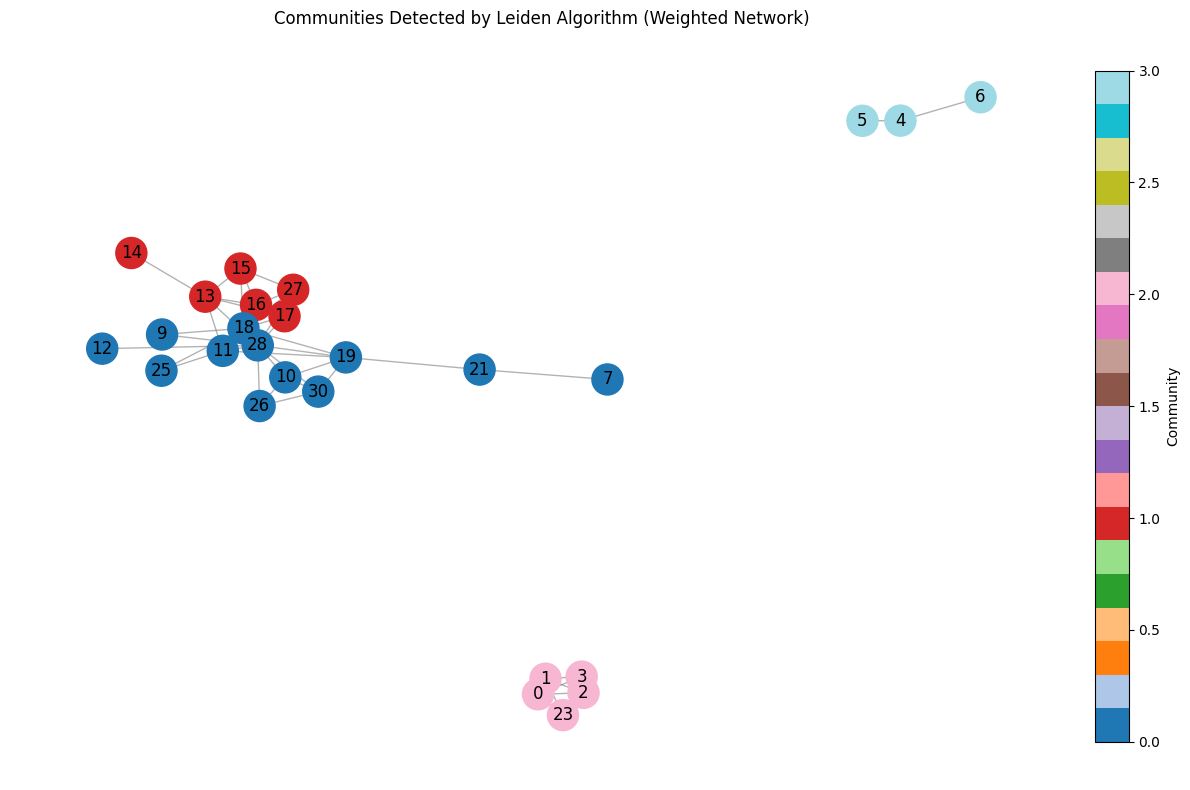

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import leidenalg as la
import igraph as ig

# 读取图数据（每行：学院1 学院2 公共课程数）
G_nx = nx.read_weighted_edgelist('courses5.txt')
G_nx = G_nx.to_undirected()

# 度中心性（用于可视化参考，基于无权连接数）
degree_centrality = nx.degree_centrality(G_nx)

# === 转换为 igraph 格式（leidenalg 依赖 igraph）===
node_list = list(G_nx.nodes())
node_to_idx = {node: idx for idx, node in enumerate(node_list)}
idx_to_node = {idx: node for node, idx in node_to_idx.items()}

# 构建边和权重列表（按 igraph 节点索引）
edges = [(node_to_idx[u], node_to_idx[v]) for u, v in G_nx.edges()]
weights = [G_nx[u][v]['weight'] for u, v in G_nx.edges()]

# 创建 igraph 图
G_ig = ig.Graph()
G_ig.add_vertices(len(node_list))
G_ig.add_edges(edges)
G_ig.es['weight'] = weights  # 设置边权重

# === 使用 Leiden 算法（使用 RB 分区以支持 resolution_parameter）===
partition_ig = la.find_partition(
    G_ig,
    la.RBConfigurationVertexPartition,
    weights='weight',
    resolution_parameter=1.0,  # ≈ 标准模块度；可调（>1 更细，<1 更粗）
    seed=42  # 部分版本支持，确保可复现
)

# 获取社区分配（membership 是节点索引对应的社区 ID 列表）
community_ids = partition_ig.membership

# 映射回原始节点名称
community_map = {}
communities_dict = {}
for idx, comm_id in enumerate(community_ids):
    node = idx_to_node[idx]
    community_map[node] = comm_id
    communities_dict.setdefault(comm_id, []).append(node)

# 转为 list of lists（用于 NetworkX 指标计算）
communities = list(communities_dict.values())

# === 打印基本信息 ===
num_communities = len(communities)
total_nodes = G_nx.number_of_nodes()
print(f"Number of communities: {num_communities}")
print(f"Total number of nodes (colleges): {total_nodes}\n")

# 按社区 ID 排序输出成员
for comm_id in sorted(communities_dict.keys()):
    print(f"Community {comm_id}: {communities_dict[comm_id]}")
print()

# === 计算标准模块度（使用 NetworkX，确保与贪心/Louvain 可比）===
# 注意：必须转为 list of sets 或 list of lists
modularity_value = nx.algorithms.community.modularity(G_nx, communities, weight='weight')
print(f"Modularity: {modularity_value:.6f}")

# === 覆盖度（Coverage）===
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G_nx, community_map)
print(f"Coverage: {coverage_value:.6f}")

# === 表现评分（Performance）===
def compute_performance(G, communities, community_map):
    n = G.number_of_nodes()
    total_possible = n * (n - 1) / 2
    actual_edges = set(tuple(sorted(e)) for e in G.edges())
    
    intra_edges = sum(1 for u, v in actual_edges if community_map[u] == community_map[v])
    inter_edges = len(actual_edges) - intra_edges
    
    possible_intra = sum(len(c) * (len(c) - 1) / 2 for c in communities)
    possible_inter = total_possible - possible_intra
    
    missing_inter = possible_inter - inter_edges  # 应无边且确实无边
    correct = intra_edges + missing_inter
    
    return correct / total_possible if total_possible > 0 else 0

performance_value = compute_performance(G_nx, communities, community_map)
print(f"Performance: {performance_value:.6f}")

# === 可视化 ===
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_nx, seed=42)  # 固定布局

# 节点颜色（按社区 ID）
community_colors = [community_map[node] for node in G_nx.nodes()]

nx.draw_networkx_nodes(G_nx, pos, node_color=community_colors, cmap=plt.cm.tab20, node_size=500)
nx.draw_networkx_labels(G_nx, pos, font_size=12)
nx.draw_networkx_edges(G_nx, pos, edge_color='gray', width=1, alpha=0.6)

# 添加颜色条
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Communities Detected by Leiden Algorithm (Weighted Network)')
plt.gca().set_facecolor('white')
plt.axis('off')
plt.tight_layout()
plt.show()

Number of communities: 4
Total number of nodes (colleges): 29

Community 0: ['17', '28', '16', '11', '18', '13', '14', '15', '27', '25', '9', '12', '20']
Community 1: ['0', '1', '2', '3', '23', '22']
Community 2: ['10', '19', '30', '21', '26', '7']
Community 3: ['4', '5', '6', '8']



C:\Users\司伟\AppData\Local\Temp\ipykernel_25076\2745201281.py:138: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=widths, alpha=0.8, ax=ax)


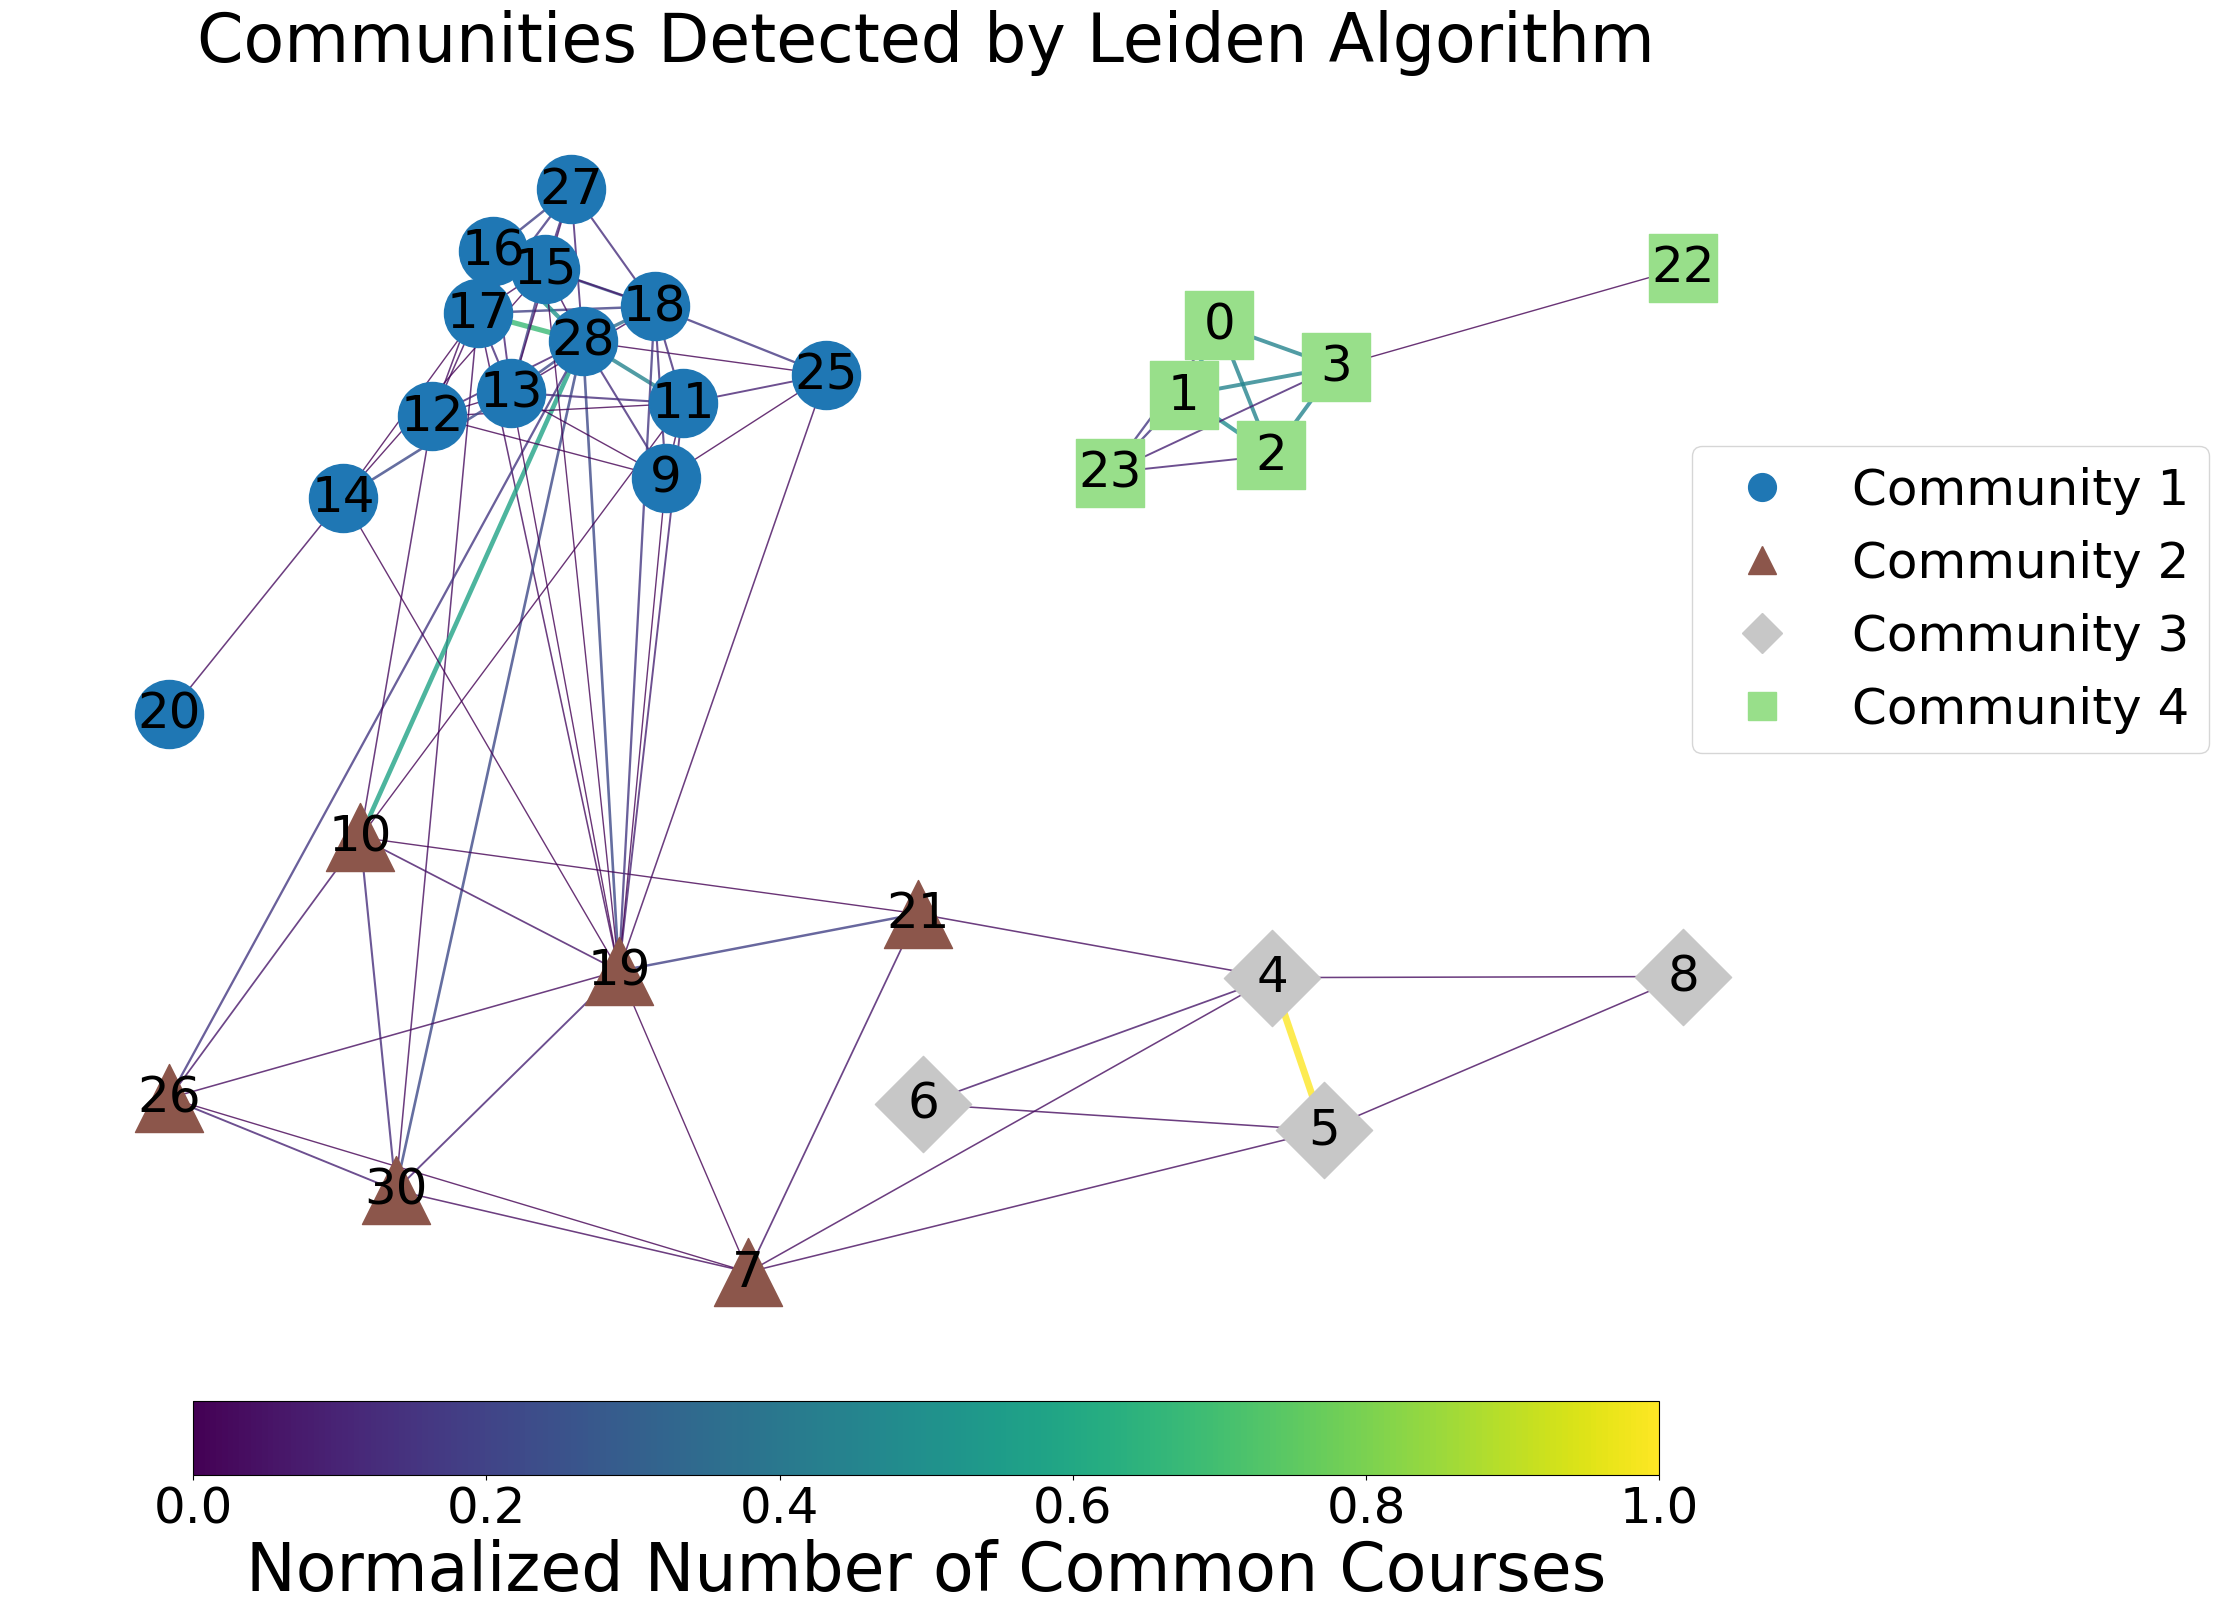

In [15]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable, tab20
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.colors import Normalize
import leidenalg as la
import igraph as ig
import math

# 读取图数据
G = nx.read_weighted_edgelist('courses3.txt')
G = G.to_undirected()

# 计算度中心性（用于排序/参考）
degree_centrality = nx.degree_centrality(G)
sorted_centrality = sorted(degree_centrality.items(), key=lambda item: item[1], reverse=True)

# === 【核心修改】使用 Leiden 算法进行社区检测 ===
# 转换为 igraph
node_list = list(G.nodes())
node_to_idx = {node: idx for idx, node in enumerate(node_list)}
idx_to_node = {idx: node for node, idx in node_to_idx.items()}

edges = [(node_to_idx[u], node_to_idx[v]) for u, v in G.edges()]
weights = [G[u][v]['weight'] for u, v in G.edges()]

G_ig = ig.Graph()
G_ig.add_vertices(len(node_list))
G_ig.add_edges(edges)
G_ig.es['weight'] = weights

# 使用 Leiden（RB 分区支持 resolution）
partition_ig = la.find_partition(
    G_ig,
    la.RBConfigurationVertexPartition,
    weights='weight',
    resolution_parameter=1.0,
    seed=42
)

# 构建 community_map 和 communities（格式与 greedy_modularity_communities 一致）
community_ids = partition_ig.membership
community_map = {}
communities_dict = {}
for idx, comm_id in enumerate(community_ids):
    node = idx_to_node[idx]
    community_map[node] = comm_id
    communities_dict.setdefault(comm_id, []).append(node)

# 按 community_id 排序，确保顺序稳定
sorted_comm_ids = sorted(communities_dict.keys())
communities = [communities_dict[cid] for cid in sorted_comm_ids]

# 重新构建 community_map 以匹配新顺序（可选，但推荐）
community_map = {}
for comm_index, community in enumerate(communities):
    for node in community:
        community_map[node] = comm_index

# 打印信息
num_communities = len(communities)
print(f"Number of communities: {num_communities}")
total_nodes = G.number_of_nodes()
print(f"Total number of nodes (colleges): {total_nodes}\n")

for comm_id, community in enumerate(communities):
    print(f"Community {comm_id}: {list(community)}")
print()

# ========== 以下完全复用你原有的可视化代码 ==========
nodes = list(degree_centrality.keys())
centrality_values = list(degree_centrality.values())

shapes = ['o', 's', '^', 'D', 'P', '*', 'v', 'H', 'X', '8']
colors = [tab20(i / num_communities) for i in range(num_communities)]

fig, ax = plt.subplots(figsize=(25, 18))

# 布局：每个社区独立子图
pos = {}
grid_size = math.ceil(math.sqrt(num_communities))
gap = 2

for i, community in enumerate(communities):
    row = i // grid_size
    col = i % grid_size
    center_x = col * gap
    center_y = -row * gap

    subgraph = G.subgraph(community)
    sub_pos = nx.spring_layout(subgraph, seed=42, k=0.75, iterations=50)
    for node, (x, y) in sub_pos.items():
        pos[node] = (center_x + x, center_y + y)

# 自定义社区名称和图例顺序
renamed_communities = {0: 'Community 1', 1: 'Community 4', 2: 'Community 2', 3: 'Community 3'}
ordered_indices = [0, 2, 3, 1]  # 注意：确保索引不超过实际社区数！

legend_handles = []

for i in ordered_indices:
    if i >= num_communities:
        continue  # 防止索引越界
    shape = shapes[i % len(shapes)]
    color = colors[i % len(colors)]
    nodes_in_community = [n for n in G.nodes() if community_map[n] == i]

    for node in nodes_in_community:
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=[node],
            node_color=[color],
            node_shape=shape,
            node_size=2400,
            ax=ax
        )

    legend_handles.append(
        mlines.Line2D([], [], color=color, marker=shape, linestyle='None',
                      markersize=20, label=renamed_communities[i])
    )

# 节点标签
nx.draw_networkx_labels(G, pos, font_size=36, ax=ax)

# 边：按权重着色
weights_attr = nx.get_edge_attributes(G, 'weight')
if weights_attr:
    max_w = max(weights_attr.values())
    min_w = min(weights_attr.values())
    norm_weights = {k: (v - min_w) / (max_w - min_w) if max_w != min_w else 0.5
                    for k, v in weights_attr.items()}
    
    edge_colors = [plt.cm.viridis(norm_weights[edge]) for edge in G.edges()]
    widths = [1 + norm_weights[edge] * 4 for edge in G.edges()]

    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=widths, alpha=0.8, ax=ax)

    sm_edges = ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=1))
    sm_edges.set_array([])
    cbar_edges = plt.colorbar(sm_edges, ax=ax, orientation='horizontal', pad=0.01, shrink=0.8)
    cbar_edges.set_label('Normalized Number of Common Courses', fontsize=48)
    cbar_edges.ax.tick_params(labelsize=36)

# 图例
ax.legend(handles=legend_handles, title="", fontsize=36, title_fontsize=28,
          loc='right', bbox_to_anchor=(1.20, 0.6), borderaxespad=0.)

ax.set_title('Communities Detected by Leiden Algorithm', fontsize=48)
ax.set_facecolor('white')
ax.axis('off')
plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])
plt.savefig("D:/作业合集/数字化市场分析/leiden.pdf", format='pdf', dpi=600, bbox_inches='tight')
plt.show()

Number of communities: 4
Total number of nodes (colleges): 29

Community 0: ['17', '28', '16', '11', '18', '13', '14', '15', '27', '25', '9', '12', '20']
Community 1: ['0', '1', '2', '3', '23', '22']
Community 2: ['10', '19', '30', '21', '26', '7']
Community 3: ['4', '5', '6', '8']



C:\Users\司伟\AppData\Local\Temp\ipykernel_25076\4009572491.py:111: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(subgraph, pos, edge_color=edge_colors, width=widths, alpha=0.8, ax=ax)
C:\Users\司伟\AppData\Local\Temp\ipykernel_25076\4009572491.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.9])


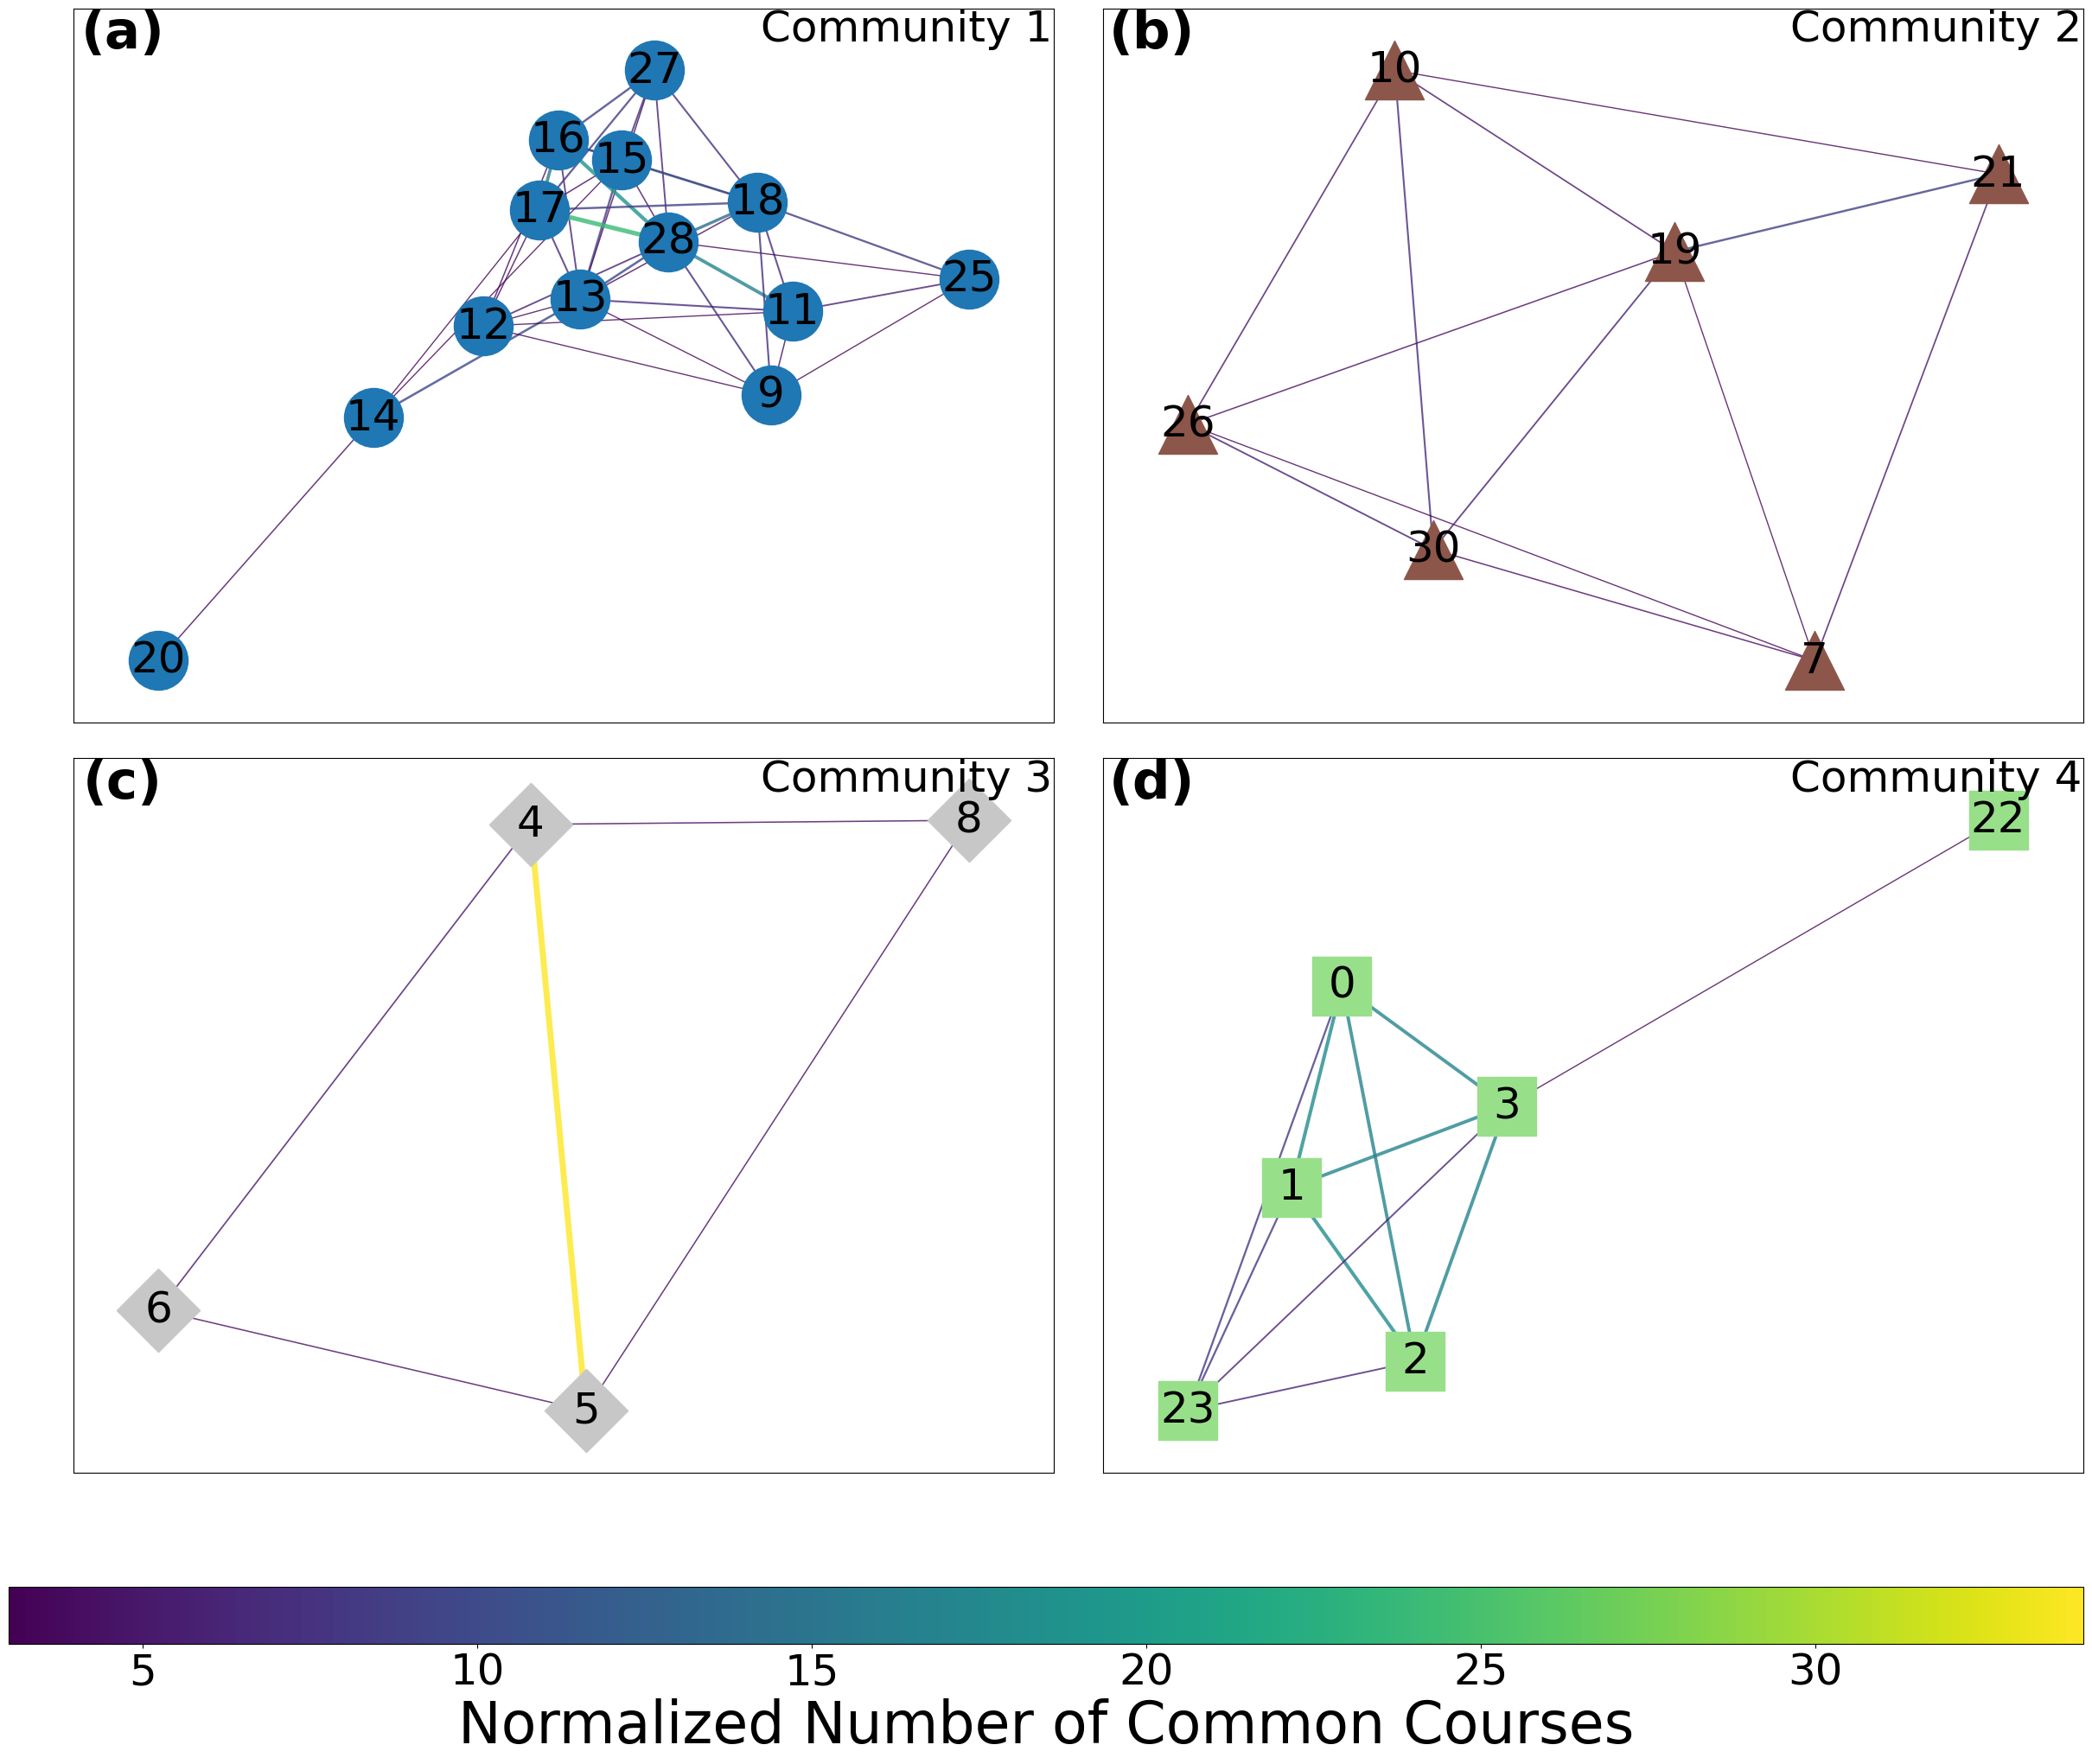

In [16]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable, tab20
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.colors import Normalize
import leidenalg as la
import igraph as ig
import math

# 读取图数据
G = nx.read_weighted_edgelist('courses3.txt')
G = G.to_undirected()

# 计算度中心性（用于排序/参考）
degree_centrality = nx.degree_centrality(G)
sorted_centrality = sorted(degree_centrality.items(), key=lambda item: item[1], reverse=True)

# === 【核心修改】使用 Leiden 算法进行社区检测 ===
# 转换为 igraph
node_list = list(G.nodes())
node_to_idx = {node: idx for idx, node in enumerate(node_list)}
idx_to_node = {idx: node for node, idx in node_to_idx.items()}

edges = [(node_to_idx[u], node_to_idx[v]) for u, v in G.edges()]
weights = [G[u][v]['weight'] for u, v in G.edges()]

G_ig = ig.Graph()
G_ig.add_vertices(len(node_list))
G_ig.add_edges(edges)
G_ig.es['weight'] = weights

# 使用 Leiden（RB 分区支持 resolution）
partition_ig = la.find_partition(
    G_ig,
    la.RBConfigurationVertexPartition,
    weights='weight',
    resolution_parameter=1.0,
    seed=42
)

# 构建 community_map 和 communities（格式与 greedy_modularity_communities 一致）
community_ids = partition_ig.membership
community_map = {}
communities_dict = {}
for idx, comm_id in enumerate(community_ids):
    node = idx_to_node[idx]
    community_map[node] = comm_id
    communities_dict.setdefault(comm_id, []).append(node)

# 按 community_id 排序，确保顺序稳定
sorted_comm_ids = sorted(communities_dict.keys())
communities = [communities_dict[cid] for cid in sorted_comm_ids]

# 重新构建 community_map 以匹配新顺序（可选，但推荐）
community_map = {}
for comm_index, community in enumerate(communities):
    for node in community:
        community_map[node] = comm_index

# 打印信息
num_communities = len(communities)
print(f"Number of communities: {num_communities}")
total_nodes = G.number_of_nodes()
print(f"Total number of nodes (colleges): {total_nodes}\n")

for comm_id, community in enumerate(communities):
    print(f"Community {comm_id}: {list(community)}")
print()

# ========== 以下完全复用你原有的可视化代码 ==========
# 颜色和形状
shapes = ['o', 's', '^', 'D']
colors = [tab20(i / num_communities) for i in range(num_communities)]

# 自定义社区绘制顺序和标签
ordered_indices = [0, 2, 3, 1]  # 调整显示顺序
renamed_communities = {0: 'Community 1', 1: 'Community 4', 2: 'Community 2', 3: 'Community 3'}

# 计算全局最大最小边权重，确保颜色统一
all_weights = []
for community in communities:
    w = nx.get_edge_attributes(G.subgraph(community), 'weight').values()
    all_weights.extend(w)
global_min_weight = min(all_weights)
global_max_weight = max(all_weights)

# 创建4子图
fig, axes = plt.subplots(2, 2, figsize=(30, 22), gridspec_kw={'wspace':0.05, 'hspace':0.05})

for plot_idx, community_idx in enumerate(ordered_indices):
    row = plot_idx // 2
    col = plot_idx % 2
    ax = axes[row, col]

    community_nodes = [n for n in G.nodes() if community_map[n] == community_idx]
    subgraph = G.subgraph(community_nodes)

    # 社区内部布局
    pos = nx.spring_layout(subgraph, seed=42, k=0.75, iterations=50)

    # 绘制社区内部边，使用全局边权归一化
    weights = nx.get_edge_attributes(subgraph, 'weight')
    if weights:
        norm_weights = {
            edge: (weight - global_min_weight) / (global_max_weight - global_min_weight)
            for edge, weight in weights.items()
        }
        edge_colors = [plt.cm.viridis(norm_weights[edge]) for edge in subgraph.edges()]
        widths = [1 + norm_weights[edge] * 4 for edge in subgraph.edges()]
        nx.draw_networkx_edges(subgraph, pos, edge_color=edge_colors, width=widths, alpha=0.8, ax=ax)

    # 绘制节点
    color = colors[community_idx]
    shape = shapes[community_idx]
    nx.draw_networkx_nodes(subgraph, pos,
                           node_color=[color],
                           node_shape=shape,
                           node_size=2400,
                           ax=ax)

    # 绘制标签
    nx.draw_networkx_labels(subgraph, pos, font_size=36, ax=ax)

   
    ax.text(0.85, 1.0, renamed_communities[community_idx],
            transform=ax.transAxes,
            fontsize=36, ha='center', va='top')

    # 单独在下方加上 (a)/(b)/(c)/(d)，字号更大
    subplot_labels = ['(a)', '(b)', '(c)', '(d)']
    ax.text(0.05, 1.0, subplot_labels[plot_idx],
            transform=ax.transAxes,
            fontsize=44, ha='center', va='top', fontweight='bold')




# 添加统一颜色条
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis,
                           norm=mcolors.Normalize(vmin=global_min_weight, vmax=global_max_weight))
sm.set_array([])

cbar_ax = fig.add_axes([0.1, 0.02, 0.8, 0.03])
cbar = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Normalized Number of Common Courses', fontsize=48)
cbar.ax.tick_params(labelsize=36)

# 图例
#legend_handles = []
#for i in ordered_indices:
    #legend_handles.append(
        #mlines.Line2D([], [], color=colors[i], marker=shapes[i], linestyle='None',
                      #markersize=20, label=renamed_communities[i])
    #)
#fig.legend(handles=legend_handles, fontsize=36, title_fontsize=28,
           #loc='upper center', bbox_to_anchor=(0.5, 1.05), borderaxespad=0.)

plt.tight_layout(rect=[0, 0.05, 1, 0.9])
plt.savefig("D:/作业合集/数字化市场分析/leiden四.pdf", format='pdf', dpi=600, bbox_inches='tight')
plt.show()